In [5]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [6]:
dt = pd.read_csv("../DataSets/credit_record.csv")

In [7]:
de = pd.read_csv("../DataSets/application_record.csv")

In [8]:
df = pd.merge(dt,de,on='ID')

In [9]:
df

,ID,MONTHS_BALANCE,STATUS,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,0,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008804,-1,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008804,-2,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
3,5008804,-3,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
4,5008804,-4,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777710,5150487,-25,C,M,Y,N,0,202500.0,Working,Secondary / secondary special,Married,House / apartment,-19398,-2166,1,0,0,0,Drivers,2.0
777711,5150487,-26,C,M,Y,N,0,202500.0,Working,Secondary / secondary special,Married,House / apartment,-19398,-2166,1,0,0,0,Drivers,2.0
777712,5150487,-27,C,M,Y,N,0,202500.0,Working,Secondary / secondary special,Married,House / apartment,-19398,-2166,1,0,0,0,Drivers,2.0
777713,5150487,-28,C,M,Y,N,0,202500.0,Working,Secondary / secondary special,Married,House / apartment,-19398,-2166,1,0,0,0,Drivers,2.0


In [10]:
df.rename(columns={
    'AMT_INCOME_TOTAL': 'Annual_Income',
    'CNT_FAM_MEMBERS': 'Family_Member_Count',
    'DAYS_BIRTH': 'Age_Days',
    'DAYS_EMPLOYED': 'Employment_Days',
    'NAME_INCOME_TYPE': 'Income_Type',
    'OCCUPATION_TYPE': 'Occupation_Type'},inplace=True)

In [11]:
df

,ID,MONTHS_BALANCE,STATUS,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,Annual_Income,Income_Type,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,Age_Days,Employment_Days,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,Occupation_Type,Family_Member_Count
0,5008804,0,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008804,-1,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008804,-2,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
3,5008804,-3,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
4,5008804,-4,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777710,5150487,-25,C,M,Y,N,0,202500.0,Working,Secondary / secondary special,Married,House / apartment,-19398,-2166,1,0,0,0,Drivers,2.0
777711,5150487,-26,C,M,Y,N,0,202500.0,Working,Secondary / secondary special,Married,House / apartment,-19398,-2166,1,0,0,0,Drivers,2.0
777712,5150487,-27,C,M,Y,N,0,202500.0,Working,Secondary / secondary special,Married,House / apartment,-19398,-2166,1,0,0,0,Drivers,2.0
777713,5150487,-28,C,M,Y,N,0,202500.0,Working,Secondary / secondary special,Married,House / apartment,-19398,-2166,1,0,0,0,Drivers,2.0


In [12]:
df.isnull().sum()

ID                          0
MONTHS_BALANCE              0
STATUS                      0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
Annual_Income               0
Income_Type                 0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
Age_Days                    0
Employment_Days             0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
Occupation_Type        240048
Family_Member_Count         0
dtype: int64

In [13]:
df.Occupation_Type.unique()

array([nan, 'Security staff', 'Sales staff', 'Accountants', 'Laborers',
       'Managers', 'Drivers', 'Core staff', 'High skill tech staff',
       'Cleaning staff', 'Private service staff', 'Cooking staff',
       'Low-skill Laborers', 'Medicine staff', 'Secretaries',
       'Waiters/barmen staff', 'HR staff', 'Realty agents', 'IT staff'],
      dtype=object)

In [14]:
df.Occupation_Type.mode()

0    Laborers
Name: Occupation_Type, dtype: object

In [15]:
df.Occupation_Type = df.Occupation_Type.fillna('Laborers')

In [16]:
df.STATUS.unique()

array(['C', '1', '0', 'X', '5', '4', '3', '2'], dtype=object)

In [17]:
df['Credit_Risk'] = df['STATUS']

In [18]:
df.Occupation_Type.value_counts()

Occupation_Type
Laborers                 371620
Core staff                77112
Sales staff               70362
Managers                  67738
Drivers                   47678
High skill tech staff     31768
Accountants               27223
Medicine staff            26691
Cooking staff             13416
Security staff            12400
Cleaning staff            11399
Private service staff      6714
Low-skill Laborers         3623
Secretaries                3149
Waiters/barmen staff       2557
HR staff                   1686
IT staff                   1319
Realty agents              1260
Name: count, dtype: int64

In [19]:
df.Credit_Risk = df.Credit_Risk.replace(['2','3','4','5'],1)
df.Credit_Risk = df.Credit_Risk.replace(['1','0','C','X'],0)

C:\Users\Sarang\AppData\Local\Temp\ipykernel_10040\3118559122.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.Credit_Risk = df.Credit_Risk.replace(['1','0','C','X'],0)


In [20]:
df.Credit_Risk.unique()

array([0, 1])

## EDA

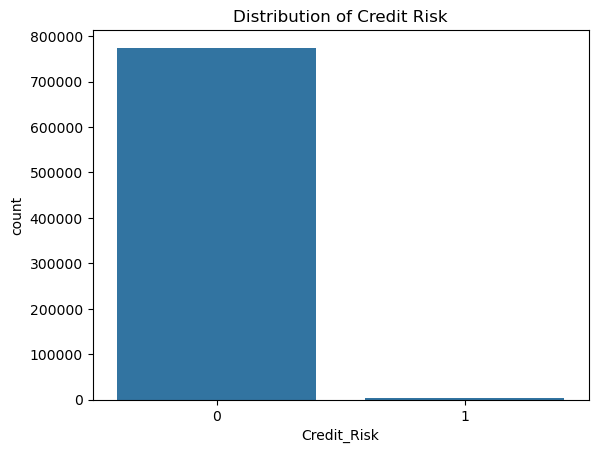

Credit_Risk
0    774887
1      2828
Name: count, dtype: int64

In [21]:
## 1)What is the distribution of the Credit_Risk variable (Good (0) vs Bad (1))?

sb.countplot(x= df.Credit_Risk)
plt.title("Distribution of Credit Risk")
plt.show()
df.Credit_Risk.value_counts()

The dataset is highly imbalanced, with the majority of customers classified as Good credit risk (0) and only a very small proportion classified as Bad credit risk (1).

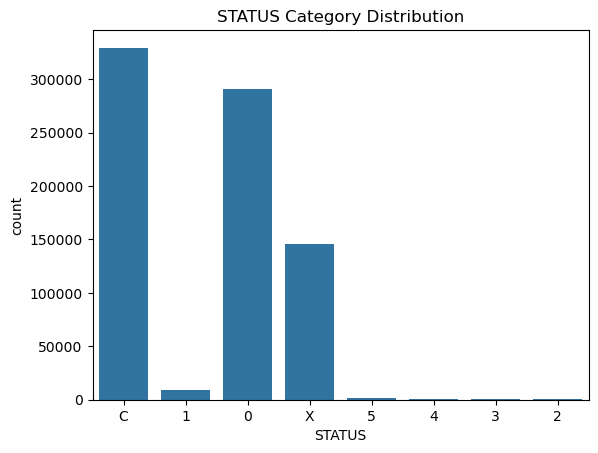

STATUS
C    329536
0    290654
X    145950
1      8747
5      1527
2       801
3       286
4       214
Name: count, dtype: int64

In [22]:
## 2) Which STATUS category occurs most frequently?

sb.countplot(x=df.STATUS)
plt.title("STATUS Category Distribution")
plt.show()
df.STATUS.value_counts()

The most frequent STATUS category is “C”, indicating that the majority of records fall under this status compared to all other categories.

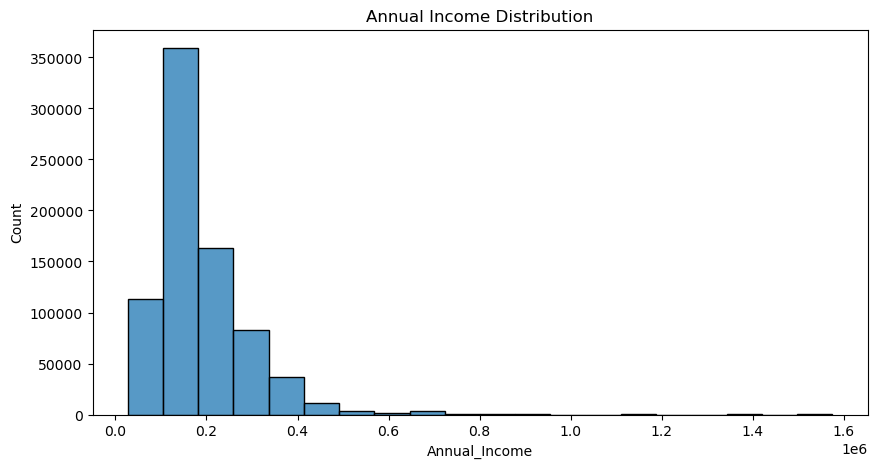

In [23]:
## 3)What is the distribution of Annual Income?

plt.figure(figsize=([10,5]))
sb.histplot(x =df.Annual_Income,bins=20)
plt.title("Annual Income Distribution")
plt.show()

The Annual Income distribution appears to be right-skewed, with most individuals having lower to moderate incomes and a smaller number earning very high incomes.

In [24]:
df['Age_Days'] = abs(df['Age_Days']) // 365
df['Employment_Days'] = abs(df['Employment_Days']) // 365
df

,ID,MONTHS_BALANCE,STATUS,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,Annual_Income,Income_Type,NAME_EDUCATION_TYPE,...,NAME_HOUSING_TYPE,Age_Days,Employment_Days,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,Occupation_Type,Family_Member_Count,Credit_Risk
0,5008804,0,C,M,Y,Y,0,427500.0,Working,Higher education,...,Rented apartment,32,12,1,1,0,0,Laborers,2.0,0
1,5008804,-1,C,M,Y,Y,0,427500.0,Working,Higher education,...,Rented apartment,32,12,1,1,0,0,Laborers,2.0,0
2,5008804,-2,C,M,Y,Y,0,427500.0,Working,Higher education,...,Rented apartment,32,12,1,1,0,0,Laborers,2.0,0
3,5008804,-3,C,M,Y,Y,0,427500.0,Working,Higher education,...,Rented apartment,32,12,1,1,0,0,Laborers,2.0,0
4,5008804,-4,C,M,Y,Y,0,427500.0,Working,Higher education,...,Rented apartment,32,12,1,1,0,0,Laborers,2.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777710,5150487,-25,C,M,Y,N,0,202500.0,Working,Secondary / secondary special,...,House / apartment,53,5,1,0,0,0,Drivers,2.0,0
777711,5150487,-26,C,M,Y,N,0,202500.0,Working,Secondary / secondary special,...,House / apartment,53,5,1,0,0,0,Drivers,2.0,0
777712,5150487,-27,C,M,Y,N,0,202500.0,Working,Secondary / secondary special,...,House / apartment,53,5,1,0,0,0,Drivers,2.0,0
777713,5150487,-28,C,M,Y,N,0,202500.0,Working,Secondary / secondary special,...,House / apartment,53,5,1,0,0,0,Drivers,2.0,0


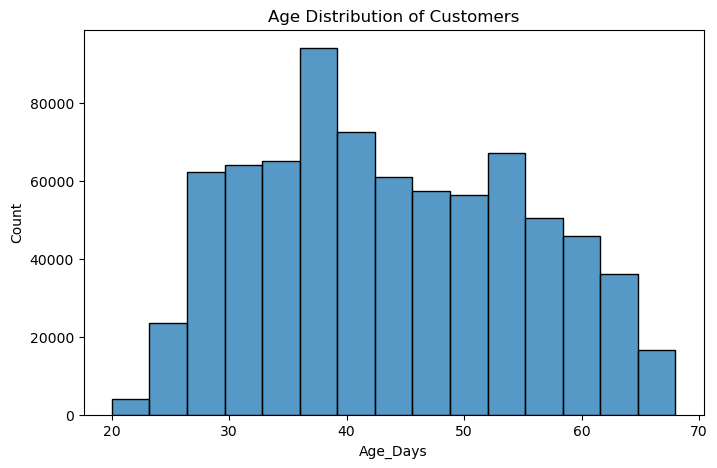

In [25]:
## 4) What is the age distribution of customers?

plt.figure(figsize=[8,5])
sb.histplot(df.Age_Days,bins=15)
plt.title("Age Distribution of Customers")
plt.show()

The customer age distribution shows that most customers belong to the middle-age group, with fewer very young or older customers.


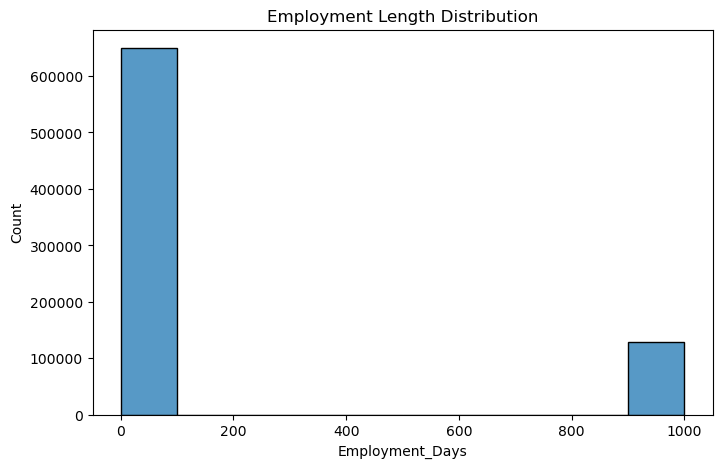

In [26]:
## 5) How is Employment Length distributed?

plt.figure(figsize=[8,5])
sb.histplot(df.Employment_Days,bins=10)
plt.title("Employment Length Distribution")
plt.show()

The Employment Length distribution indicates that most customers have shorter to moderate employment durations, while fewer customers have very long employment histories.


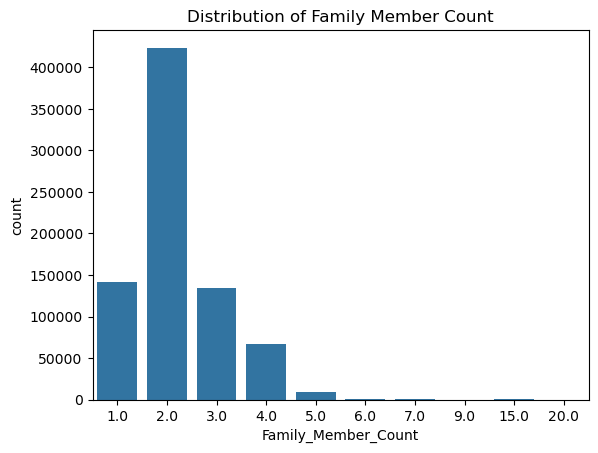

In [27]:
## 6) What is the distribution of Family Member Count?

sb.countplot(x = df.Family_Member_Count)
plt.title('Distribution of Family Member Count')
plt.show()

The distribution of Family Member Count shows that most customers belong to small families with fewer family members.


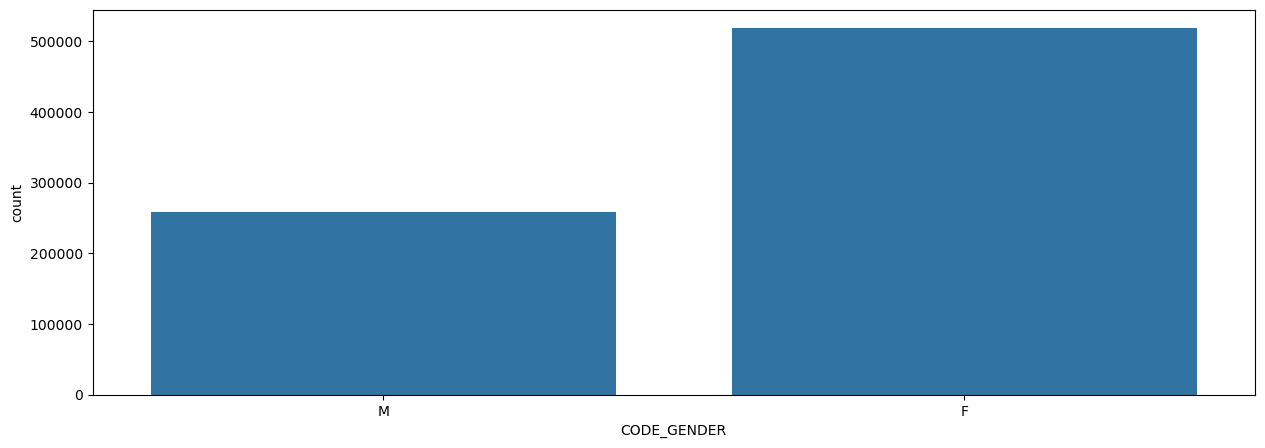

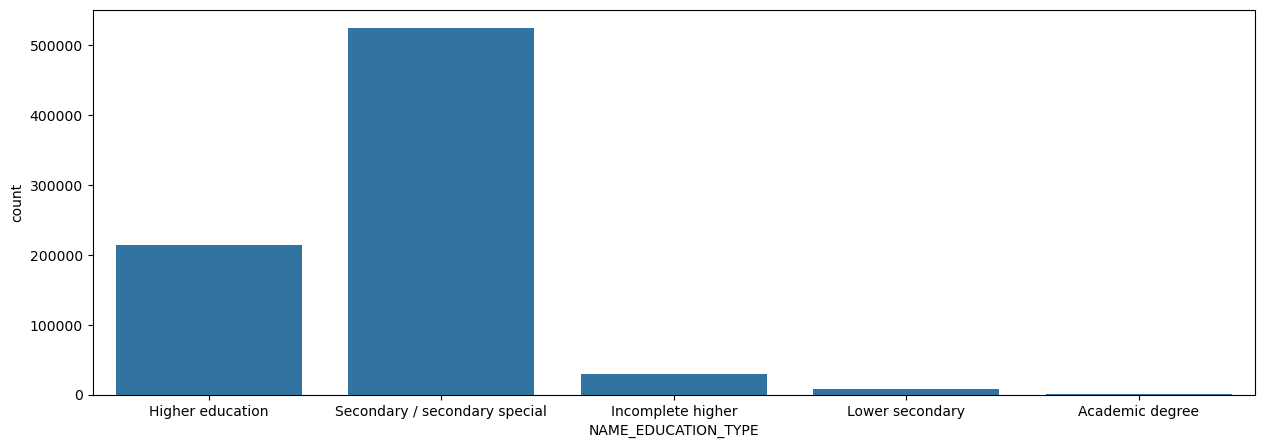

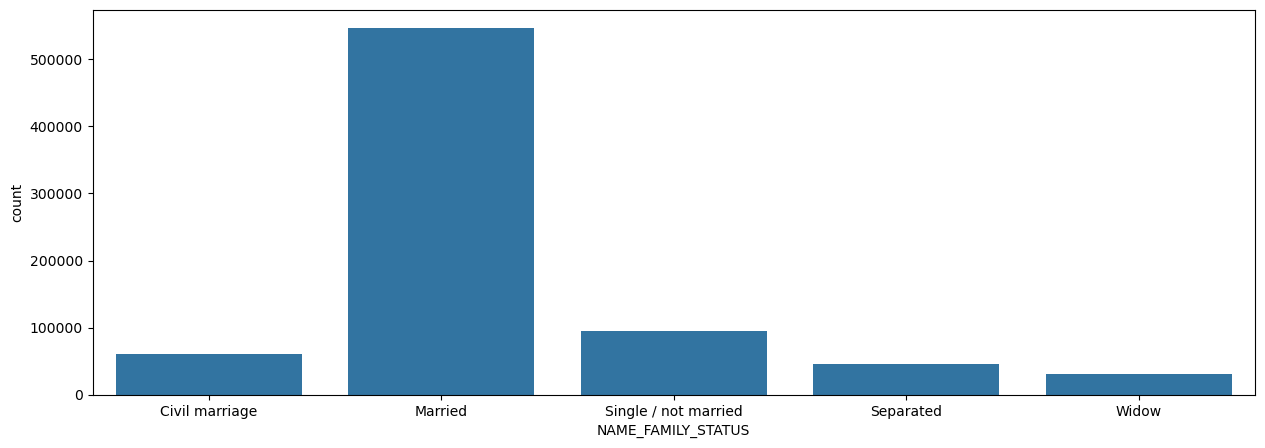

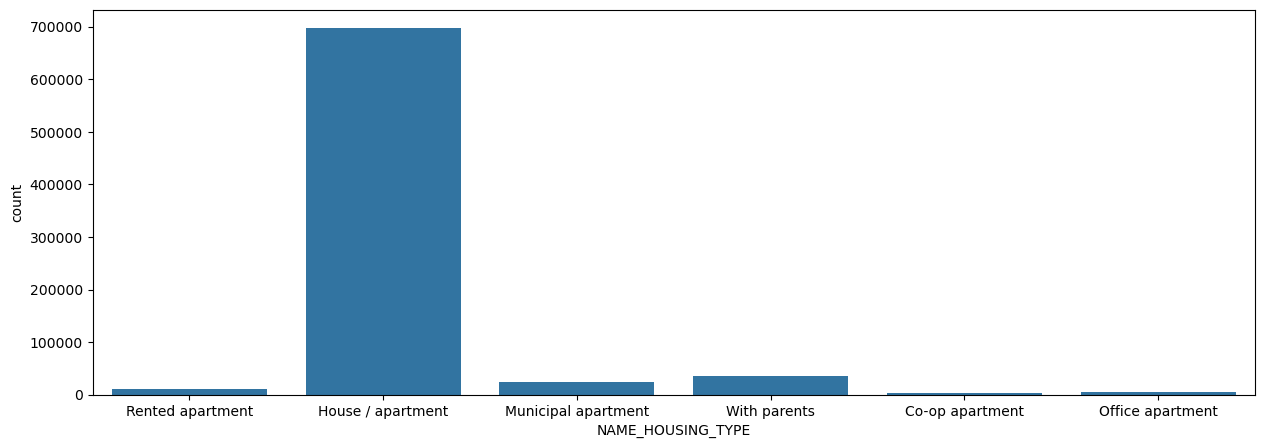

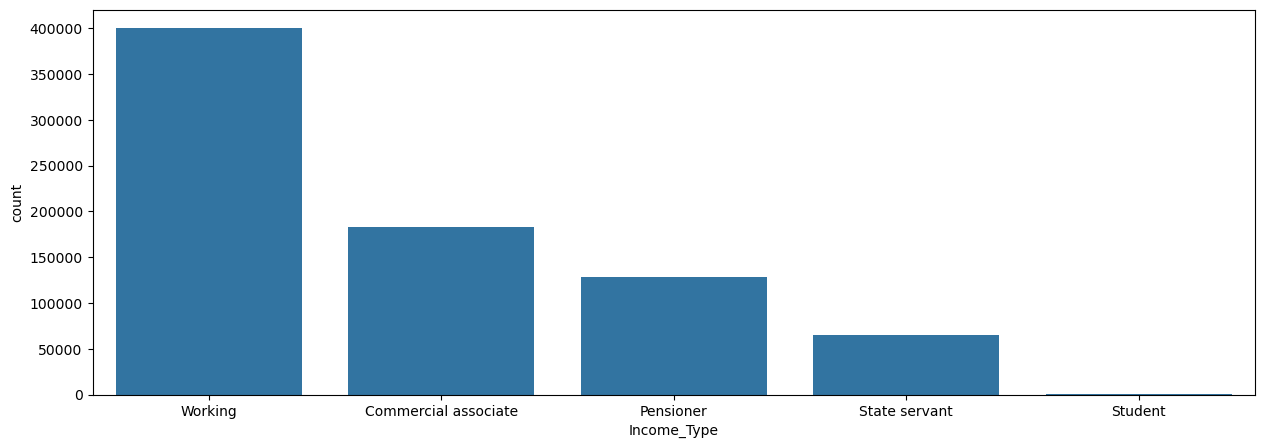

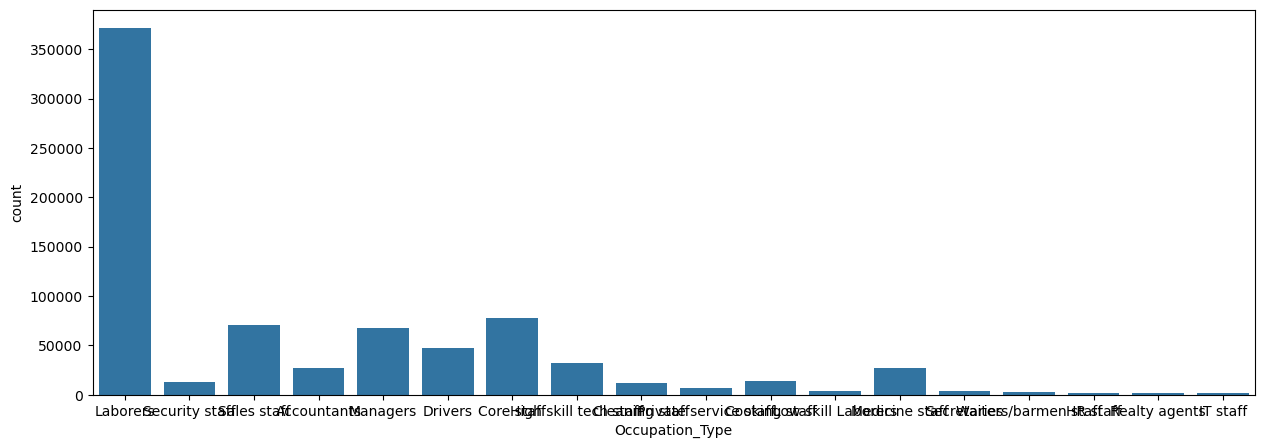

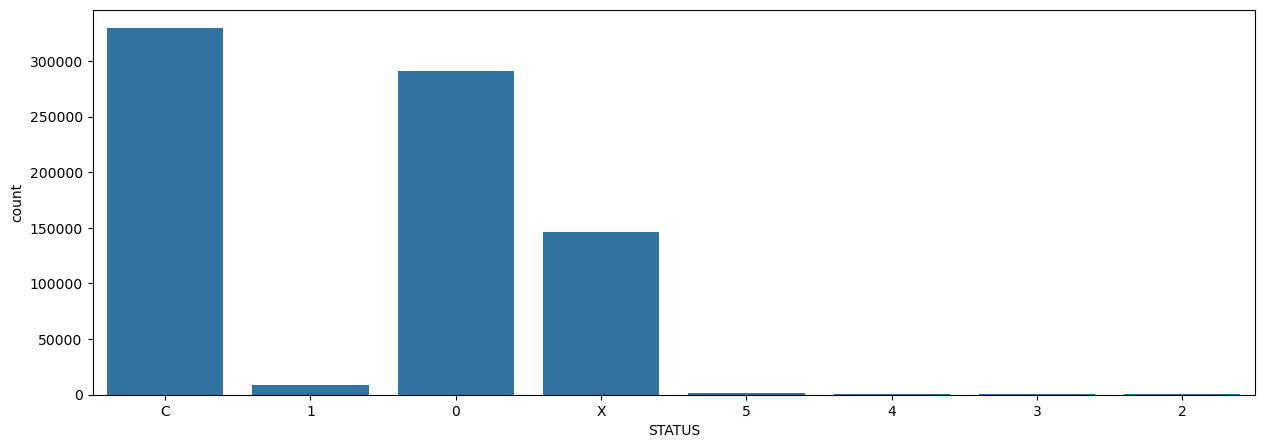

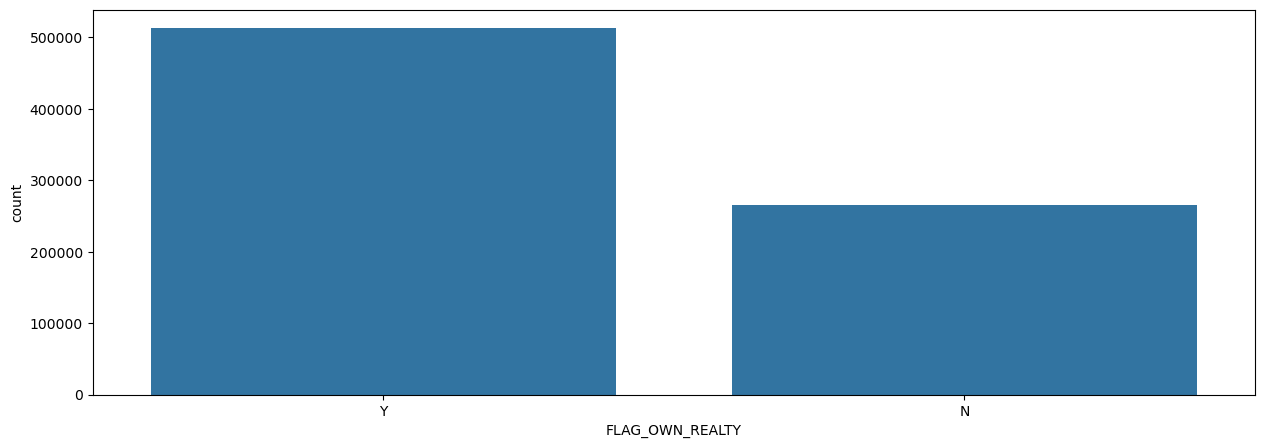

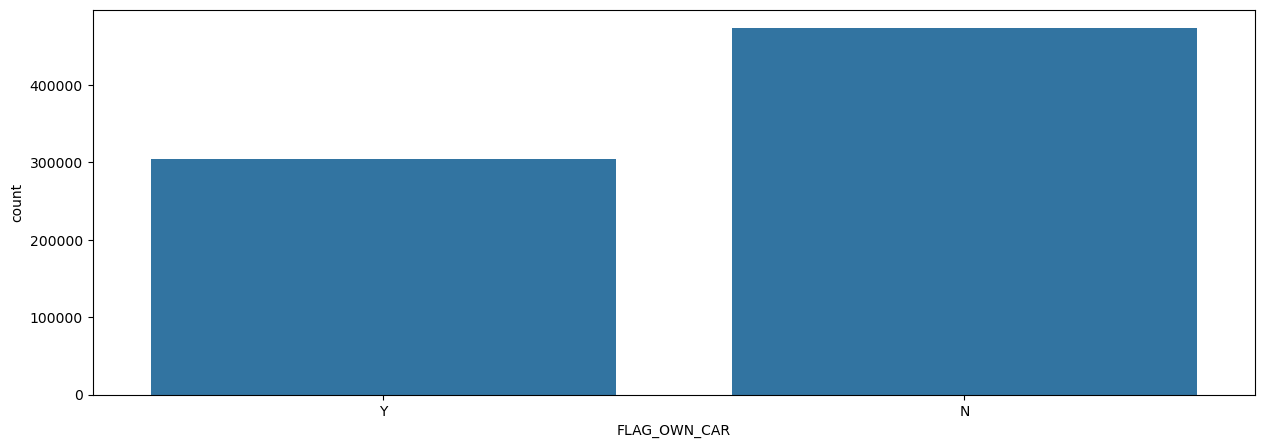

In [28]:
## 7) How are categorical features distributed?

categorical = ['CODE_GENDER','NAME_EDUCATION_TYPE','NAME_FAMILY_STATUS','NAME_HOUSING_TYPE','Income_Type',
               'Occupation_Type','STATUS','FLAG_OWN_REALTY','FLAG_OWN_CAR']

for col in categorical:
    plt.figure(figsize=[15,5])
    sb.countplot(x = df[col])
    plt.show()

The categorical features show uneven distributions, where certain categories dominate each variable while some categories have comparatively very few records.


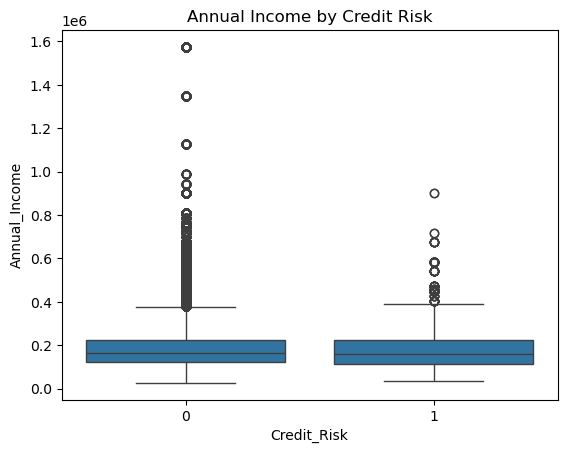

In [29]:
## 8) How does Annual Income vary between good (0) and bad (1) credit customers?

sb.boxplot(x=df.Credit_Risk , y=df.Annual_Income)
plt.title("Annual Income by Credit Risk")
plt.show()

The boxplot suggests that Annual Income levels are fairly similar for both good and bad credit customers, with some income outliers present in each group.


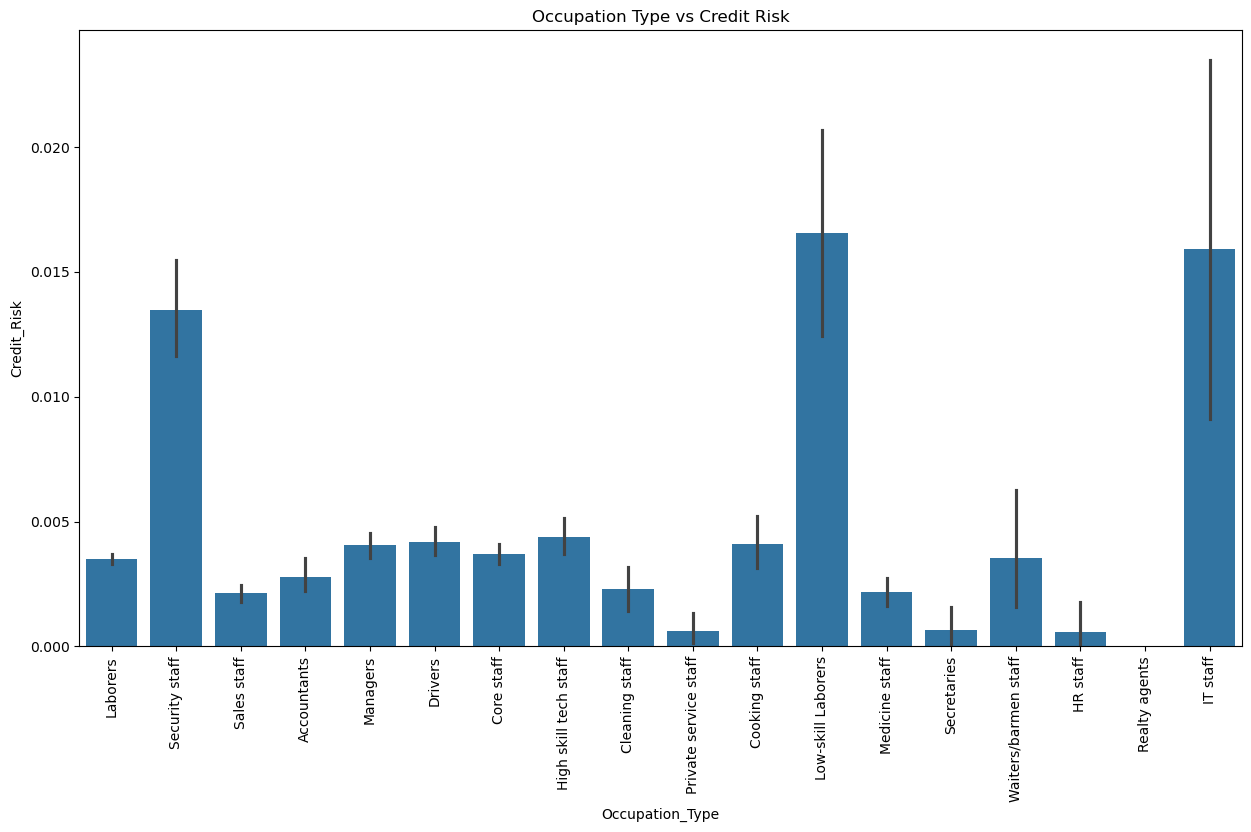

In [30]:
## 9)Are certain Occupation Types associated with higher bad credit risk?

plt.figure(figsize=[15,8])
sb.barplot(x=df.Occupation_Type , y=df.Credit_Risk)
plt.xticks(rotation=90)
plt.title("Occupation Type vs Credit Risk")
plt.show()

Certain occupation types show relatively higher average bad credit risk, indicating that credit risk may vary depending on the customer’s occupation category.


In [31]:
## 10) What is the correlation between numerical features?

df.corr(numeric_only=True)

,ID,MONTHS_BALANCE,CNT_CHILDREN,Annual_Income,Age_Days,Employment_Days,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,Family_Member_Count,Credit_Risk
ID,1.000000,0.005007,0.026269,-0.027597,-0.041938,-0.025921,NaN,0.084800,0.006346,-0.056083,0.027375,0.010690
MONTHS_BALANCE,0.005007,1.000000,0.000913,0.001831,-0.035813,-0.005456,NaN,0.001529,-0.005120,0.005288,-0.006276,-0.004405
CNT_CHILDREN,0.026269,0.000913,1.000000,0.039304,-0.356017,-0.231170,NaN,0.042226,-0.018882,0.015726,0.892079,-0.000705
Annual_Income,-0.027597,0.001831,0.039304,1.000000,-0.081093,-0.180334,NaN,-0.021229,0.018687,0.085776,0.031379,0.003267
Age_Days,-0.041938,-0.035813,-0.356017,-0.081093,1.000000,0.617057,NaN,-0.181275,0.026586,-0.100706,-0.327615,0.005234
Employment_Days,-0.025921,-0.005456,-0.231170,-0.180334,0.617057,1.000000,NaN,-0.243825,-0.012788,-0.083933,-0.229471,0.003170
FLAG_MOBIL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_WORK_PHONE,0.084800,0.001529,0.042226,-0.021229,-0.181275,-0.243825,NaN,1.000000,0.312552,-0.037991,0.060183,0.007412
FLAG_PHONE,0.006346,-0.005120,-0.018882,0.018687,0.026586,-0.012788,NaN,0.312552,1.000000,0.011901,-0.007824,0.007213
FLAG_EMAIL,-0.056083,0.005288,0.015726,0.085776,-0.100706,-0.083933,NaN,-0.037991,0.011901,1.000000,0.012540,-0.003054


The correlation matrix indicates that most numerical features have weak correlations with each other, suggesting limited linear relationships among the variables.


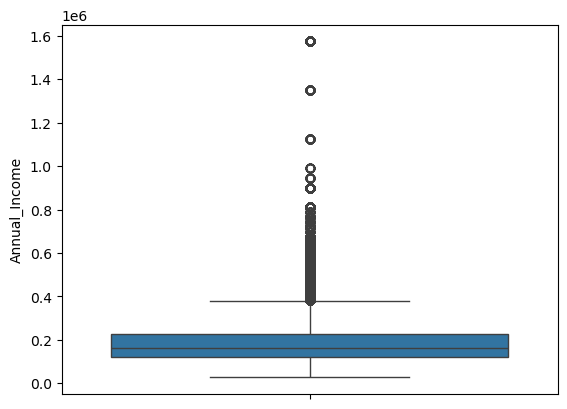

In [32]:
## 11) Are there extreme outliers in Annual Income?

sb.boxplot(df.Annual_Income)
plt.show()

The boxplot reveals the presence of extreme outliers in Annual Income, with a few customers earning significantly higher incomes than the majority.


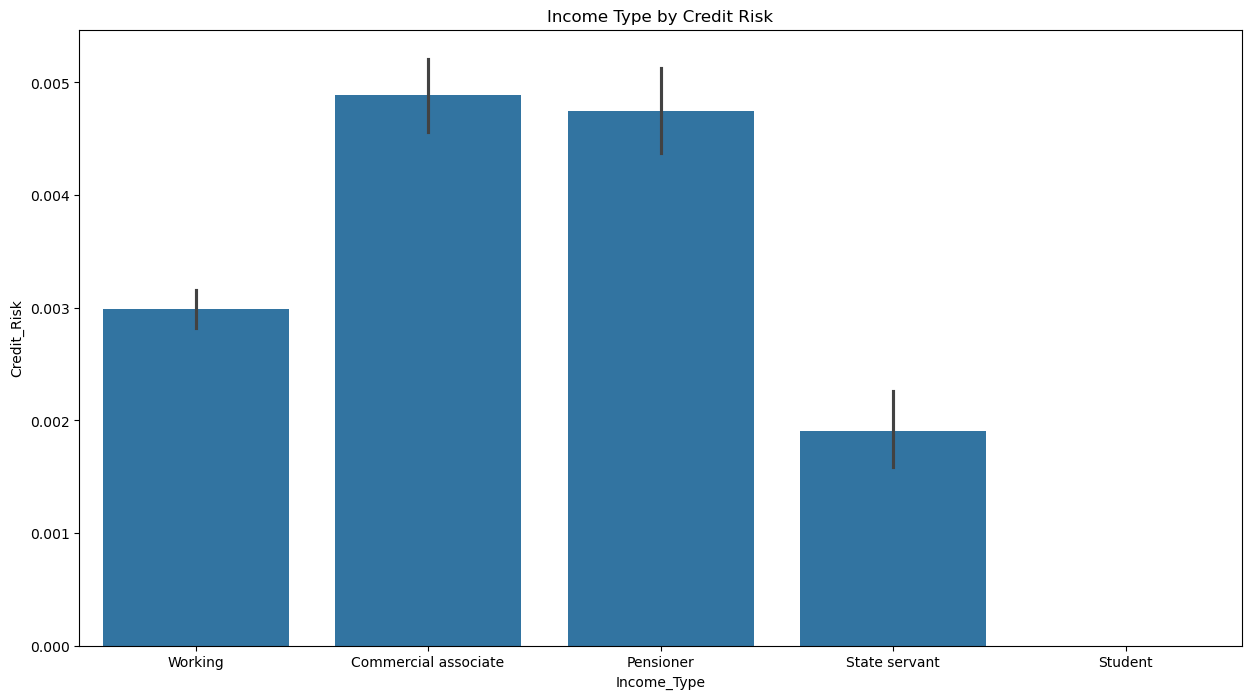

In [33]:
## 12) How does credit risk vary by Income Type?

plt.figure(figsize=[15,8])
sb.barplot(x=df.Income_Type , y=df.Credit_Risk)
plt.title("Income Type by Credit Risk")
plt.show()

Credit risk varies across different income types, with some income categories showing a comparatively higher proportion of bad credit risk customers.


## ML

In [34]:
df

,ID,MONTHS_BALANCE,STATUS,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,Annual_Income,Income_Type,NAME_EDUCATION_TYPE,...,NAME_HOUSING_TYPE,Age_Days,Employment_Days,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,Occupation_Type,Family_Member_Count,Credit_Risk
0,5008804,0,C,M,Y,Y,0,427500.0,Working,Higher education,...,Rented apartment,32,12,1,1,0,0,Laborers,2.0,0
1,5008804,-1,C,M,Y,Y,0,427500.0,Working,Higher education,...,Rented apartment,32,12,1,1,0,0,Laborers,2.0,0
2,5008804,-2,C,M,Y,Y,0,427500.0,Working,Higher education,...,Rented apartment,32,12,1,1,0,0,Laborers,2.0,0
3,5008804,-3,C,M,Y,Y,0,427500.0,Working,Higher education,...,Rented apartment,32,12,1,1,0,0,Laborers,2.0,0
4,5008804,-4,C,M,Y,Y,0,427500.0,Working,Higher education,...,Rented apartment,32,12,1,1,0,0,Laborers,2.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777710,5150487,-25,C,M,Y,N,0,202500.0,Working,Secondary / secondary special,...,House / apartment,53,5,1,0,0,0,Drivers,2.0,0
777711,5150487,-26,C,M,Y,N,0,202500.0,Working,Secondary / secondary special,...,House / apartment,53,5,1,0,0,0,Drivers,2.0,0
777712,5150487,-27,C,M,Y,N,0,202500.0,Working,Secondary / secondary special,...,House / apartment,53,5,1,0,0,0,Drivers,2.0,0
777713,5150487,-28,C,M,Y,N,0,202500.0,Working,Secondary / secondary special,...,House / apartment,53,5,1,0,0,0,Drivers,2.0,0


In [35]:
df=df.drop(['ID','STATUS','CODE_GENDER','CNT_CHILDREN','Age_Days','FLAG_MOBIL','FLAG_WORK_PHONE','FLAG_PHONE','FLAG_EMAIL'], axis=1)

In [36]:
df

,MONTHS_BALANCE,FLAG_OWN_CAR,FLAG_OWN_REALTY,Annual_Income,Income_Type,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,Employment_Days,Occupation_Type,Family_Member_Count,Credit_Risk
0,0,Y,Y,427500.0,Working,Higher education,Civil marriage,Rented apartment,12,Laborers,2.0,0
1,-1,Y,Y,427500.0,Working,Higher education,Civil marriage,Rented apartment,12,Laborers,2.0,0
2,-2,Y,Y,427500.0,Working,Higher education,Civil marriage,Rented apartment,12,Laborers,2.0,0
3,-3,Y,Y,427500.0,Working,Higher education,Civil marriage,Rented apartment,12,Laborers,2.0,0
4,-4,Y,Y,427500.0,Working,Higher education,Civil marriage,Rented apartment,12,Laborers,2.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
777710,-25,Y,N,202500.0,Working,Secondary / secondary special,Married,House / apartment,5,Drivers,2.0,0
777711,-26,Y,N,202500.0,Working,Secondary / secondary special,Married,House / apartment,5,Drivers,2.0,0
777712,-27,Y,N,202500.0,Working,Secondary / secondary special,Married,House / apartment,5,Drivers,2.0,0
777713,-28,Y,N,202500.0,Working,Secondary / secondary special,Married,House / apartment,5,Drivers,2.0,0


In [37]:
from sklearn.preprocessing import LabelEncoder
label=LabelEncoder()

In [38]:
df.FLAG_OWN_CAR=label.fit_transform(df.FLAG_OWN_CAR)
df.FLAG_OWN_REALTY=label.fit_transform(df.FLAG_OWN_REALTY)
df.Income_Type=label.fit_transform(df.Income_Type)
df.NAME_EDUCATION_TYPE=label.fit_transform(df.NAME_EDUCATION_TYPE)
df.NAME_FAMILY_STATUS=label.fit_transform(df.NAME_FAMILY_STATUS)
df.NAME_HOUSING_TYPE=label.fit_transform(df.NAME_HOUSING_TYPE)
df.Occupation_Type=label.fit_transform(df.Occupation_Type)

In [39]:
df.dtypes

MONTHS_BALANCE           int64
FLAG_OWN_CAR             int64
FLAG_OWN_REALTY          int64
Annual_Income          float64
Income_Type              int64
NAME_EDUCATION_TYPE      int64
NAME_FAMILY_STATUS       int64
NAME_HOUSING_TYPE        int64
Employment_Days          int64
Occupation_Type          int64
Family_Member_Count    float64
Credit_Risk              int64
dtype: object

In [40]:
x = df.drop('Credit_Risk',axis = 1).values
y = df['Credit_Risk'].values

In [41]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2)

## Logistic Regression

In [42]:
from sklearn.linear_model import LogisticRegression
model1 = LogisticRegression()

In [43]:
model1.fit(xtrain,ytrain)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [44]:
ypred1 = model1.predict(xtest)
ypred1

array([0, 0, 0, ..., 0, 0, 0], shape=(155543,))

In [45]:
from sklearn.metrics import accuracy_score
acc1 = accuracy_score(ytest,ypred1)
acc1 * 100

99.63482766823321

Your Logistic Regression model achieved **99.63% accuracy**, but the convergence warning and prediction results suggest the model is likely biased toward predicting only the majority class (Good Credit Risk = 0) due to severe class imbalance in the dataset.


## Random forest

In [46]:
from sklearn.ensemble import RandomForestClassifier
model2 = RandomForestClassifier()

In [47]:
model2.fit(xtrain,ytrain)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [48]:
ypred2 = model2.predict(xtest)
ypred2

array([0, 0, 0, ..., 0, 0, 0], shape=(155543,))

In [49]:
acc2 = accuracy_score(ytest,ypred2)
acc2 * 100

99.63418475919842

In [50]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(ytest,ypred2)
mse

0.00365815240801579

The Random Forest model achieved **99.64% accuracy** with a very low mean squared error, but since the predictions are mostly class 0, the model may still be affected by the severe class imbalance in the dataset.


## XG boost

In [51]:
from xgboost import XGBClassifier
model3 = XGBClassifier()

In [52]:
model3.fit(xtrain,ytrain)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [53]:
ypred3 = model3.predict(xtest)
ypred3

array([0, 0, 0, ..., 0, 0, 0], shape=(155543,))

In [54]:
acc3 = accuracy_score(ytest,ypred3)
acc3 * 100

99.67404511935605

The XGBoost model achieved the highest accuracy of **99.68%**, but since the predictions are still dominated by class 0, the model performance may be influenced by the severe imbalance between good and bad credit risk classes.


In [55]:
dd = pd.read_csv("../DataSets/application_record.csv")
r = dd.head(500)

In [56]:
r.to_csv('Credit_Risk_samples')